#**SISTEMA INTELIGENTE DE RECOMENDACIÓNDE CULTIVOS MEDIANTE MACHINE LEARNING**

## Proyecto Final — Data Science II

### 21/05/2026
### Comisión 95820
### Gastón Damiani


#**1) Introducción**

La agricultura enfrenta actualmente el desafío de producir de manera más eficiente en un contexto marcado por la variabilidad climática, la optimización de recursos y la creciente demanda alimentaria. Factores como la disponibilidad hídrica, la fertilidad del suelo, la temperatura y las precipitaciones influyen directamente sobre el desarrollo de los cultivos y condicionan la toma de decisiones agronómicas.

En este contexto, la ciencia de datos y el Machine Learning representan herramientas con gran potencial para asistir en la selección de cultivos mediante el análisis de variables climáticas y edáficas. La posibilidad de identificar patrones y relaciones entre condiciones ambientales y especies agrícolas permite desarrollar sistemas de recomendación capaces de mejorar la eficiencia productiva y reducir riesgos asociados a una elección inadecuada del cultivo.

El presente proyecto tiene como objetivo desarrollar un sistema inteligente de recomendación de cultivos utilizando técnicas de análisis exploratorio de datos y modelos de Machine Learning. Para ello, se trabajó con un dataset agrícola público que contiene información sobre nutrientes del suelo, temperatura, humedad, pH y precipitaciones, complementando además el análisis mediante el consumo de datos climáticos obtenidos desde APIs públicas.

A partir del análisis de estas variables, se entrenaron modelos de clasificación capaces de predecir el cultivo más adecuado según determinadas condiciones ambientales y nutricionales. Asimismo, el proyecto busca demostrar el potencial de la inteligencia artificial aplicada al sector agropecuario, integrando conocimientos agronómicos y analíticos orientados a la agricultura de precisión y la toma de decisiones basada en datos.

#**2) Motivación y Audiencia**

La correcta selección de cultivos representa una de las decisiones más importantes dentro de los sistemas de producción agrícola, ya que impacta directamente en la productividad, el uso eficiente de recursos y la rentabilidad del establecimiento. Variables como la disponibilidad de agua, las condiciones climáticas y la fertilidad del suelo pueden determinar el éxito o fracaso de una producción agrícola.

En los últimos años, el avance de la agricultura de precisión y las tecnologías basadas en datos ha permitido incorporar herramientas analíticas capaces de asistir en la toma de decisiones agronómicas. En este contexto, el uso de Machine Learning ofrece la posibilidad de identificar patrones complejos entre variables ambientales y productivas, permitiendo desarrollar sistemas inteligentes de recomendación agrícola.

La motivación principal de este proyecto surge del interés por integrar conocimientos de agronomía y ciencia de datos para construir soluciones aplicadas al sector agropecuario, utilizando información climática y edáfica para recomendar cultivos adecuados según distintas condiciones productivas.

La audiencia beneficiada por este análisis incluye:

* Productores agropecuarios interesados en optimizar la selección de cultivos.
* Ingenieros agrónomos y asesores técnicos.
* Empresas vinculadas a agricultura de precisión.
* Organizaciones orientadas al análisis agroclimático.
* Profesionales y estudiantes interesados en aplicaciones de Machine Learning en el agro.

#**3) Preguntas e Hipótesis**

##**Preguntas de investigación**

* ¿Existen diferencias climáticas y edáficas significativas entre los distintos tipos de cultivo?
* ¿Qué variables poseen mayor influencia en la recomendación del cultivo adecuado?
* ¿Las variables nutricionales del suelo permiten diferenciar perfiles agrícolas específicos?
* ¿La disponibilidad hídrica es un factor determinante en la selección de cultivos?
* ¿Es posible predecir el cultivo óptimo mediante modelos de Machine Learning utilizando variables climáticas y del suelo?

##**Hipótesis**

**Hipótesis 1**

Los distintos cultivos presentan requerimientos climáticos y nutricionales diferenciados, permitiendo identificar patrones específicos según variables ambientales y del suelo.

**Hipótesis 2**

Variables relacionadas con la disponibilidad hídrica, como humedad y precipitaciones, tendrán alta relevancia en la recomendación agrícola.

**Hipótesis 3**

Los nutrientes del suelo, particularmente nitrógeno, fósforo y potasio, poseen capacidad discriminatoria entre diferentes especies agrícolas.

**Hipótesis 4**

Los modelos de Machine Learning podrán clasificar correctamente los cultivos utilizando variables climáticas y edáficas, alcanzando elevados niveles de precisión predictiva.

#**4) Integración de API climática**

In [1]:
# Importamos librerías necesarias para consumir la API y guardar datos

import requests
import json

In [2]:
latitud = 31.14
longitud = 75.34

# Definimos coordenadas correspondientes a una región agrícola de Punjab, India,
# para consultar datos climáticos mediante una API pública.
# Utilizamos esta ubicación debido a que en Kaggle se menciona que los datos son
# de India.

In [3]:
# Construimos la URL de Open-Meteo para obtener datos climáticos actuales

url_api = (
    f"https://api.open-meteo.com/v1/forecast?"
    f"latitude={latitud}&longitude={longitud}"
    f"&current=temperature_2m,relative_humidity_2m,rain"
)

In [4]:
# Visualizamos la URL generada para verificar la consulta a la API

url_api

'https://api.open-meteo.com/v1/forecast?latitude=31.14&longitude=75.34&current=temperature_2m,relative_humidity_2m,rain'

In [5]:
# Realizamos la consulta a la API climática

respuesta = requests.get(url_api)

In [6]:
# Convertimos la respuesta de la API a formato JSON

datos_api = respuesta.json()

In [7]:
# Visualizamos los datos climáticos obtenidos desde la API

datos_api

{'latitude': 31.107204,
 'longitude': 75.35629,
 'generationtime_ms': 0.07903575897216797,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 221.0,
 'current_units': {'time': 'iso8601',
  'interval': 'seconds',
  'temperature_2m': '°C',
  'relative_humidity_2m': '%',
  'rain': 'mm'},
 'current': {'time': '2026-05-21T19:30',
  'interval': 900,
  'temperature_2m': 28.1,
  'relative_humidity_2m': 36,
  'rain': 0.0}}

In [8]:
# Extraemos las principales variables climáticas obtenidas desde la API

temperatura_actual = datos_api['current']['temperature_2m']

humedad_actual = datos_api['current']['relative_humidity_2m']

lluvia_actual = datos_api['current']['rain']

In [9]:
# Visualizamos los datos climáticos actuales obtenidos desde la API

print(f"Temperatura actual: {temperatura_actual} °C")

print(f"Humedad relativa: {humedad_actual} %")

print(f"Lluvia registrada: {lluvia_actual} mm")

Temperatura actual: 28.1 °C
Humedad relativa: 36 %
Lluvia registrada: 0.0 mm


In [10]:
# Guardamos los datos climáticos obtenidos desde la API en un archivo JSON local

with open('datos_climaticos_api.json', 'w') as archivo:
    json.dump(datos_api, archivo)

In [11]:
# Verificamos que el archivo JSON fue almacenado correctamente

import os

os.path.exists('datos_climaticos_api.json')

True

## Integración de API climática

Se utilizó la API pública Open-Meteo para obtener datos climáticos actuales de una región agrícola de Punjab, India. Esta ubicación fue seleccionada para mantener coherencia geográfica con el contexto original del dataset.

Las variables consultadas fueron temperatura, humedad relativa y lluvia registrada. Estos datos permiten ejemplificar cómo una solución de recomendación agrícola podría enriquecerse con información climática externa en tiempo real.

La respuesta obtenida desde la API fue almacenada localmente en formato JSON, cumpliendo con el proceso de adquisición y persistencia de datos externos.

##**5) Carga y visualización del dataset público**


In [12]:
# Importamos las librerías necesarias para el análisis de datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Definimos la URL RAW del dataset almacenado en GitHub

url = 'https://raw.githubusercontent.com/gastondamianids/Proyecto_DSII_Damiani/main/data/Crop_recommendation.csv'

In [14]:
# Cargamos el dataset desde GitHub utilizando pandas

df = pd.read_csv(url)

In [15]:
# Visualizamos las primeras filas del dataset

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


#**6) Limpieza y transformación**

In [16]:
# Traducimos el nombre de las columnas al español para facilitar
# la interpretación del análisis y las visualizaciones

df = df.rename(columns={
    'N': 'Nitrogeno',
    'P': 'Fosforo',
    'K': 'Potasio',
    'temperature': 'Temperatura',
    'humidity': 'Humedad',
    'ph': 'pH',
    'rainfall': 'Precipitaciones',
    'label': 'Cultivo'
})

In [17]:
# Traducimos los nombres de los cultivos al español para mejorar
# la interpretación de gráficos y visualizaciones

traduccion_cultivos = {
    'rice': 'Arroz',
    'maize': 'Maíz',
    'chickpea': 'Garbanzos',
    'kidneybeans': 'Porotos',
    'pigeonpeas': 'Arvejas',
    'mothbeans': 'Frijoles',
    'mungbean': 'Soja Mung',
    'blackgram': 'Poroto Negro',
    'lentil': 'Lenteja',
    'pomegranate': 'Granada',
    'banana': 'Banana',
    'mango': 'Mango',
    'grapes': 'Uvas',
    'watermelon': 'Sandía',
    'muskmelon': 'Melón',
    'apple': 'Manzana',
    'orange': 'Naranja',
    'papaya': 'Papaya',
    'coconut': 'Coco',
    'cotton': 'Algodón',
    'jute': 'Yute',
    'coffee': 'Café'
}

In [18]:
# Reemplazamos los nombres originales de los cultivos por su traducción al español

df['Cultivo'] = df['Cultivo'].replace(traduccion_cultivos)

In [19]:
# Visualizamos el nombre de todas las columnas del dataset

df.columns

Index(['Nitrogeno', 'Fosforo', 'Potasio', 'Temperatura', 'Humedad', 'pH',
       'Precipitaciones', 'Cultivo'],
      dtype='object')

##**Revisión de datos**

In [20]:
# Verificamos si existen valores nulos en el dataset

df.isnull().sum()

,0
Nitrogeno,0
Fosforo,0
Potasio,0
Temperatura,0
Humedad,0
pH,0
Precipitaciones,0
Cultivo,0


In [21]:
# Verificamos si existen registros duplicados

df.duplicated().sum()

np.int64(0)

In [22]:
# Generamos estadísticas descriptivas de las variables numéricas

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Nitrogeno,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
Fosforo,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
Potasio,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
Temperatura,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
Humedad,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
pH,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
Precipitaciones,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


In [23]:
# Guardamos el dataset procesado en formato CSV para dejar una copia local

df.to_csv('dataset_cultivos_procesado.csv', index=False)

#**7) EDA**

##**¿El dataset está balanceado entre cultivos?**

In [24]:
# Analizamos la cantidad de registros por tipo de cultivo

df['Cultivo'].value_counts()

,count
Cultivo,
Arroz,100
Maíz,100
Garbanzos,100
Porotos,100
Arvejas,100
Frijoles,100
Soja Mung,100
Poroto Negro,100
Lenteja,100


In [25]:
# Insight:
# El dataset presenta una distribución equilibrada entre los distintos tipos de cultivo,
# lo que resulta favorable para el entrenamiento de modelos de clasificación,
# ya que reduce el riesgo de sesgo hacia determinadas clases.

In [26]:
# Identificamos las variables numéricas del dataset

variables_numericas = df.select_dtypes(include=['int64', 'float64']).columns

variables_numericas

Index(['Nitrogeno', 'Fosforo', 'Potasio', 'Temperatura', 'Humedad', 'pH',
       'Precipitaciones'],
      dtype='object')

In [27]:
# Identificamos las variables categóricas del dataset

variables_categoricas = df.select_dtypes(include=['object']).columns

variables_categoricas

Index(['Cultivo'], dtype='object')

#**¿Existen relaciones fuertes entre variables del suelo y clima?**

In [28]:
# Calculamos la correlación entre las variables numéricas del dataset

correlacion = df[variables_numericas].corr()

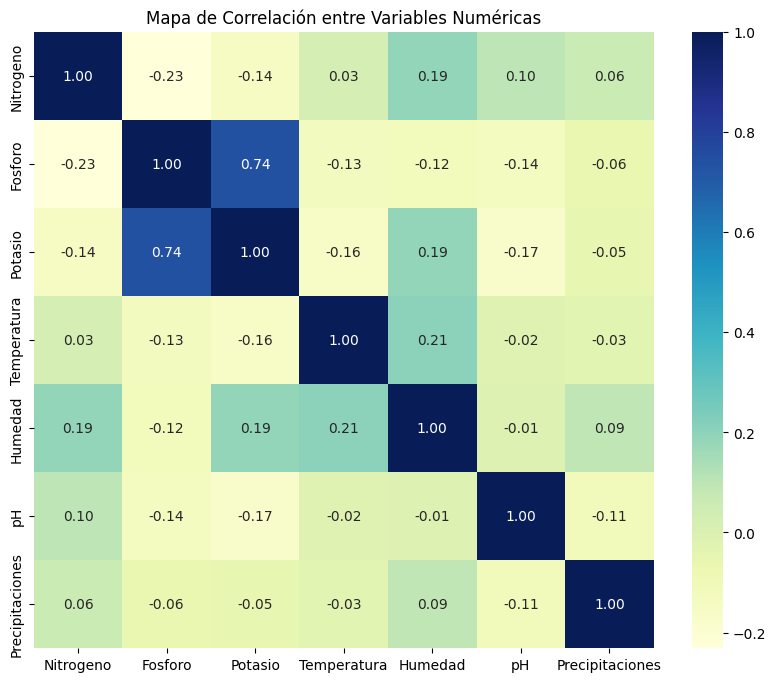

In [29]:
# Visualizamos el mapa de correlación entre variables numéricas

plt.figure(figsize=(10,8))

sns.heatmap(correlacion, annot=True, cmap='YlGnBu', fmt='.2f')

plt.title('Mapa de Correlación entre Variables Numéricas')

plt.show()

In [30]:
# Insight:
# El mapa de correlación muestra asociaciones moderadas entre algunas variables
# nutricionales y climáticas. Esto sugiere que la recomendación de cultivos
# depende de múltiples factores combinados y no únicamente de una sola variable.

Permite identificar asociaciones entre nutrientes, humedad, temperatura y precipitaciones.

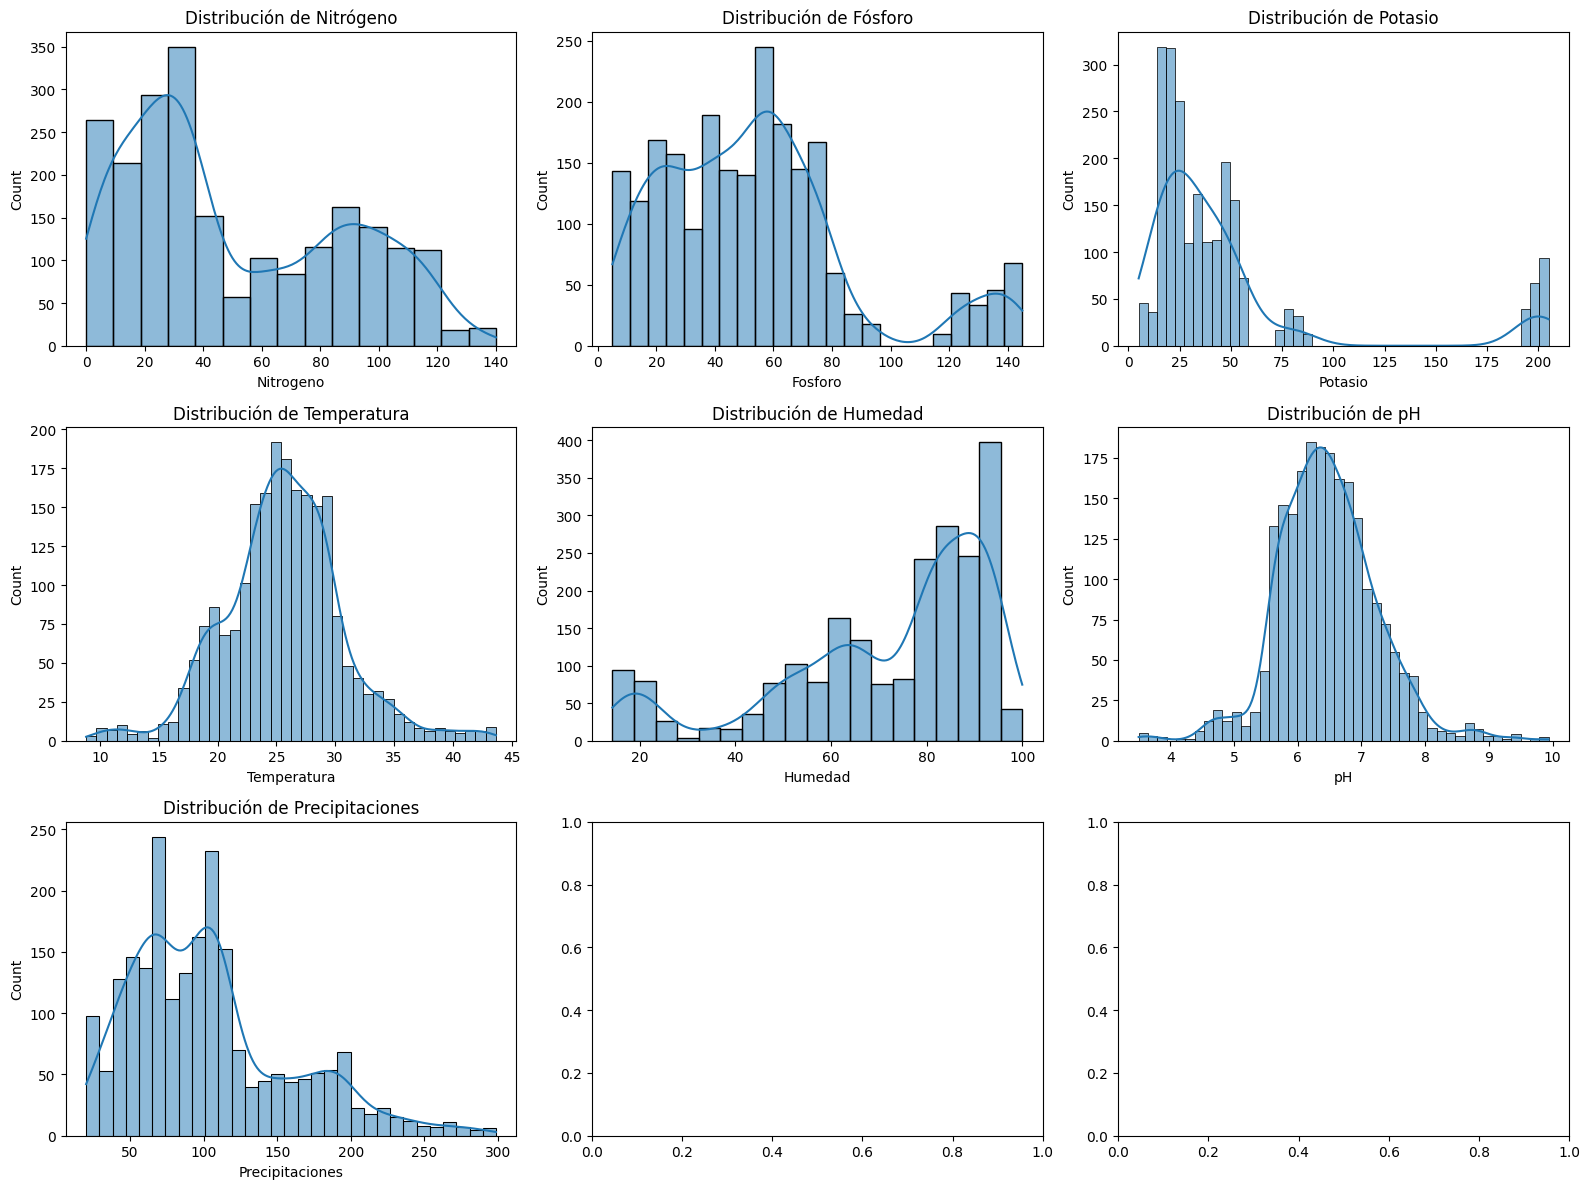

In [31]:
# Visualizamos la distribución de las variables numéricas del dataset

fig, axes = plt.subplots(3, 3, figsize=(16,12))

sns.histplot(df['Nitrogeno'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribución de Nitrógeno')

sns.histplot(df['Fosforo'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Distribución de Fósforo')

sns.histplot(df['Potasio'], kde=True, ax=axes[0,2])
axes[0,2].set_title('Distribución de Potasio')

sns.histplot(df['Temperatura'], kde=True, ax=axes[1,0])
axes[1,0].set_title('Distribución de Temperatura')

sns.histplot(df['Humedad'], kde=True, ax=axes[1,1])
axes[1,1].set_title('Distribución de Humedad')

sns.histplot(df['pH'], kde=True, ax=axes[1,2])
axes[1,2].set_title('Distribución de pH')

sns.histplot(df['Precipitaciones'], kde=True, ax=axes[2,0])
axes[2,0].set_title('Distribución de Precipitaciones')

plt.tight_layout()

plt.show()

In [32]:
# Insight:
# Las variables numéricas presentan distribuciones variadas,
# observándose diferencias importantes entre nutrientes, temperatura,
# humedad y precipitaciones. Esto sugiere la existencia de distintos
# perfiles productivos asociados a cada cultivo.

#**¿Qué rangos de temperatura son más adecuados para cada cultivo?**

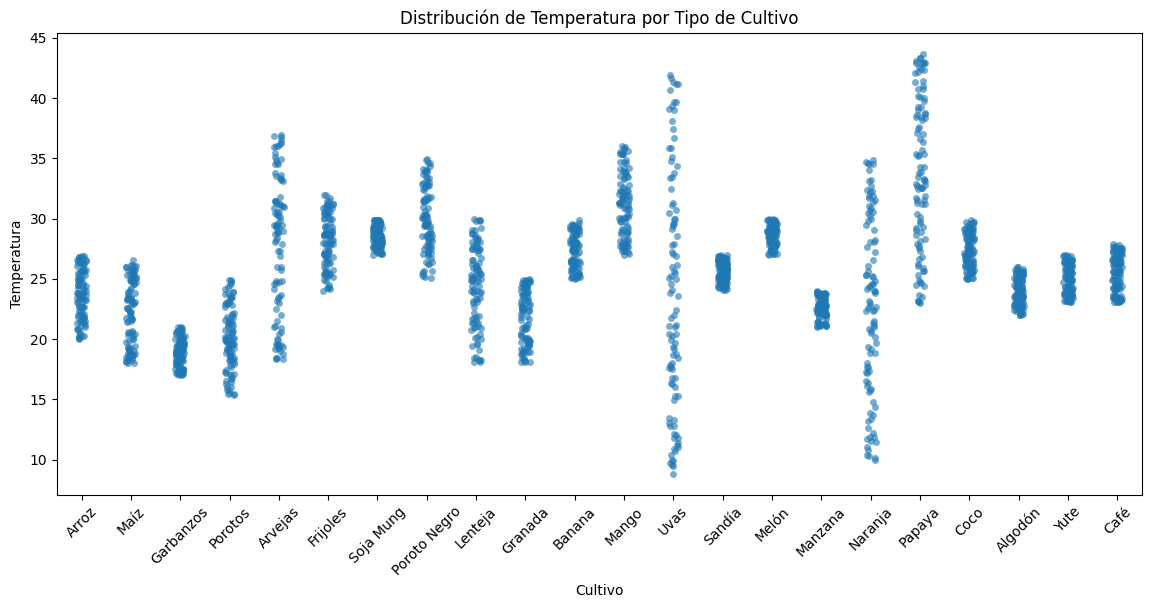

In [33]:
# Visualizamos la distribución de temperatura según el tipo de cultivo

plt.figure(figsize=(14,6))

sns.stripplot(
    data=df,
    x='Cultivo',
    y='Temperatura',
    jitter=True,
    alpha=0.6
)

plt.title('Distribución de Temperatura por Tipo de Cultivo')
plt.xlabel('Cultivo')
plt.ylabel('Temperatura')

plt.xticks(rotation=45)

plt.show()

In [34]:
# Insight:
# Se observan diferencias en los rangos de temperatura asociados a cada cultivo,
# indicando que determinadas especies agrícolas presentan mejor adaptación
# a condiciones climáticas específicas.

#**¿Cómo varía el pH óptimo entre cultivos?**

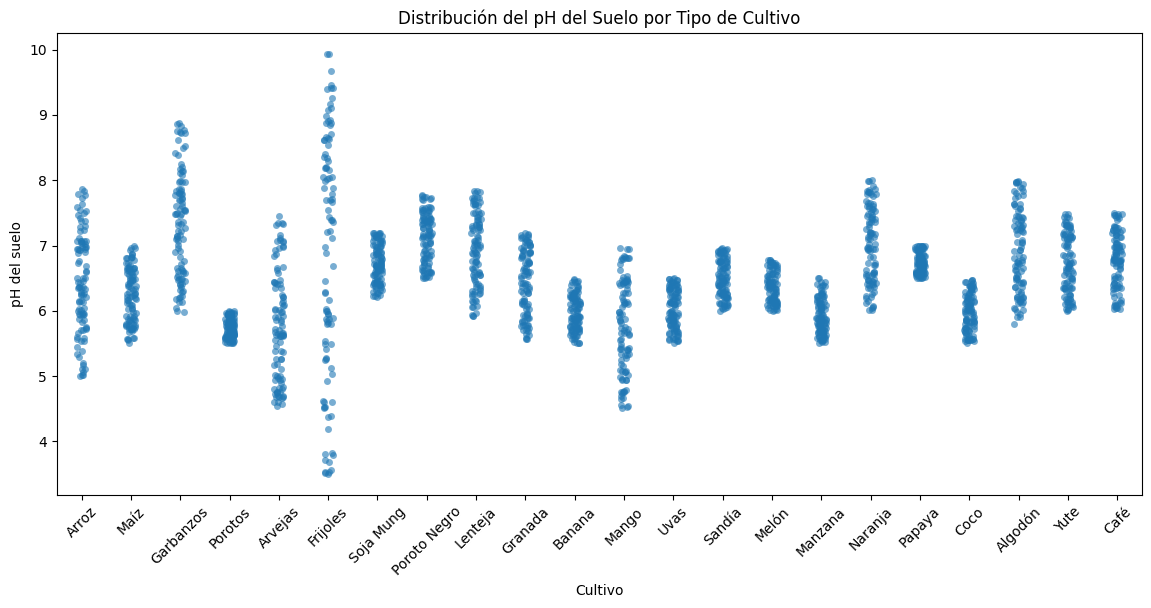

In [35]:
# Visualizamos la distribución del pH del suelo según el tipo de cultivo

plt.figure(figsize=(14,6))

sns.stripplot(
    data=df,
    x='Cultivo',
    y='pH',
    jitter=True,
    alpha=0.6
)

plt.title('Distribución del pH del Suelo por Tipo de Cultivo')
plt.xlabel('Cultivo')
plt.ylabel('pH del suelo')

plt.xticks(rotation=45)

plt.show()

In [36]:
# Insight:
# Los distintos cultivos presentan rangos de pH relativamente diferenciados,
# lo que evidencia la importancia de las características químicas del suelo
# en la selección del cultivo adecuado.

#**¿Cómo se asocia la humedad relativa con cada tipo de cultivo?**

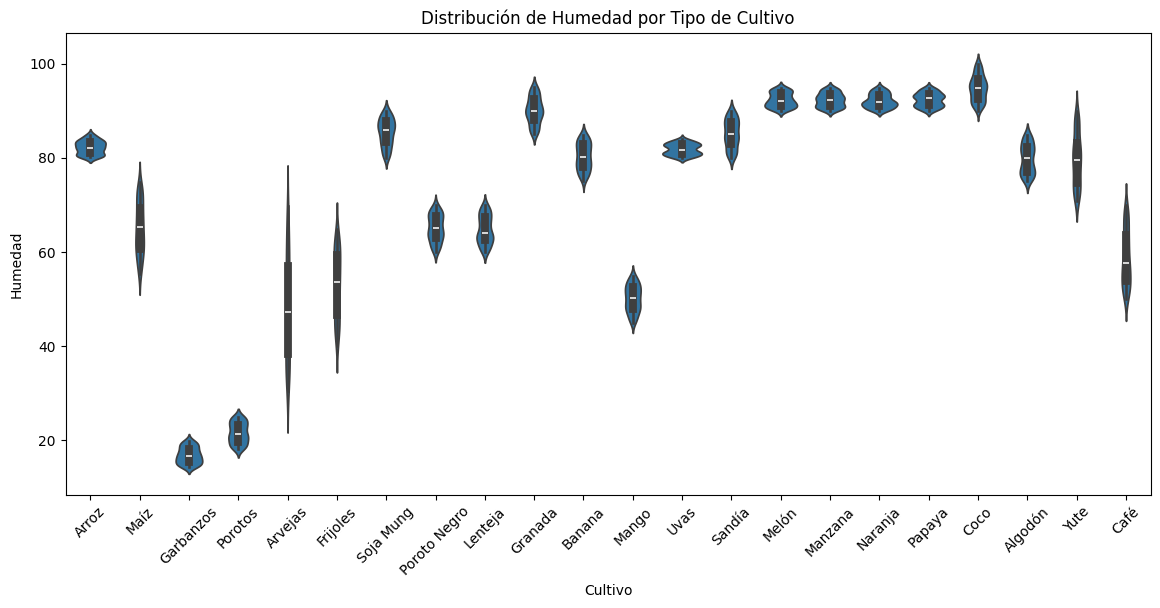

In [37]:
# Visualizamos la distribución de humedad según el tipo de cultivo

plt.figure(figsize=(14,6))

sns.violinplot(
    data=df,
    x='Cultivo',
    y='Humedad'
)

plt.title('Distribución de Humedad por Tipo de Cultivo')
plt.xlabel('Cultivo')
plt.ylabel('Humedad')

plt.xticks(rotation=45)

plt.show()

#**¿Cómo se distribuyen las precipitaciones asociadas a cada cultivo?**

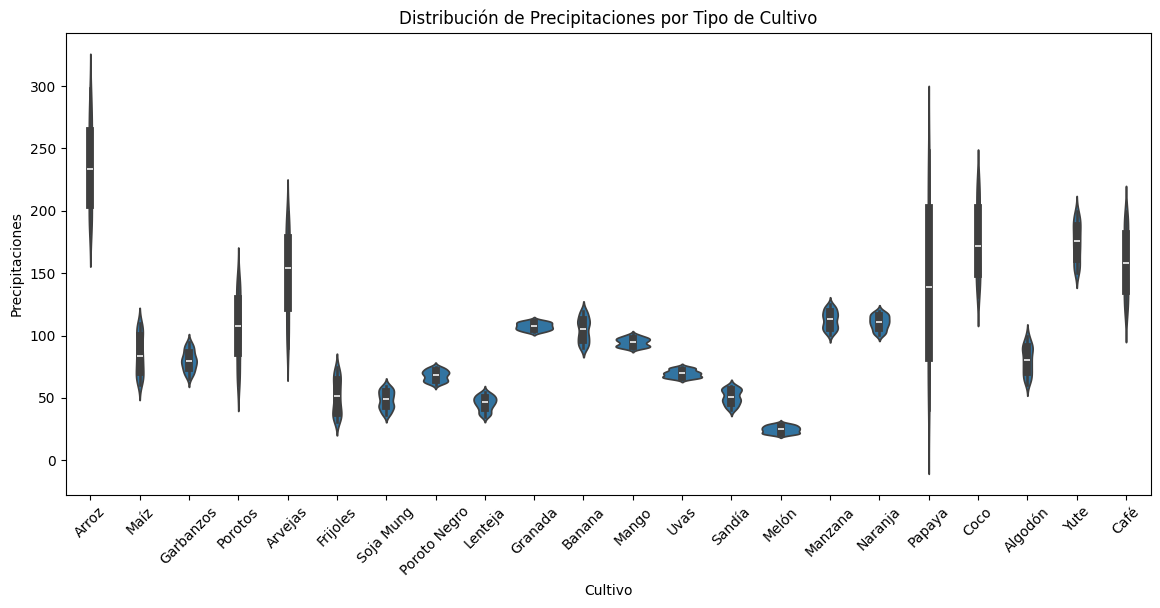

In [38]:
# Visualizamos la distribución de precipitaciones según el tipo de cultivo

plt.figure(figsize=(14,6))

sns.violinplot(
    data=df,
    x='Cultivo',
    y='Precipitaciones'
)

plt.title('Distribución de Precipitaciones por Tipo de Cultivo')
plt.xlabel('Cultivo')
plt.ylabel('Precipitaciones')

plt.xticks(rotation=45)

plt.show()

In [39]:
# Insight:
# Se observan diferencias importantes en los niveles de precipitaciones asociados
# a cada cultivo, lo que indica que la disponibilidad de agua puede ser un factor
# determinante en la selección del cultivo adecuado.

#**¿Existen perfiles nutricionales diferenciados entre cultivos?**

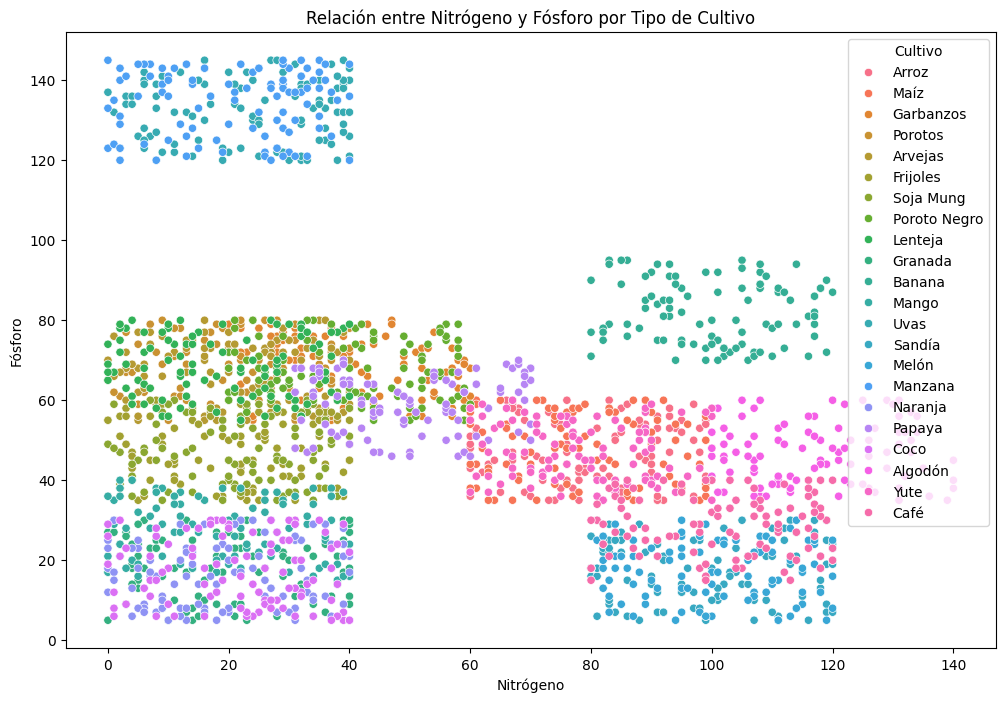

In [40]:
# Visualizamos la relación entre nitrógeno y fósforo según el tipo de cultivo

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x='Nitrogeno',
    y='Fosforo',
    hue='Cultivo'
)

plt.title('Relación entre Nitrógeno y Fósforo por Tipo de Cultivo')
plt.xlabel('Nitrógeno')
plt.ylabel('Fósforo')

plt.show()

In [41]:
# Insight:
# Se observan agrupamientos diferenciados entre cultivos según los niveles
# de nitrógeno y fósforo presentes en el suelo, lo que sugiere que estas
# variables podrían resultar relevantes para los modelos de clasificación.

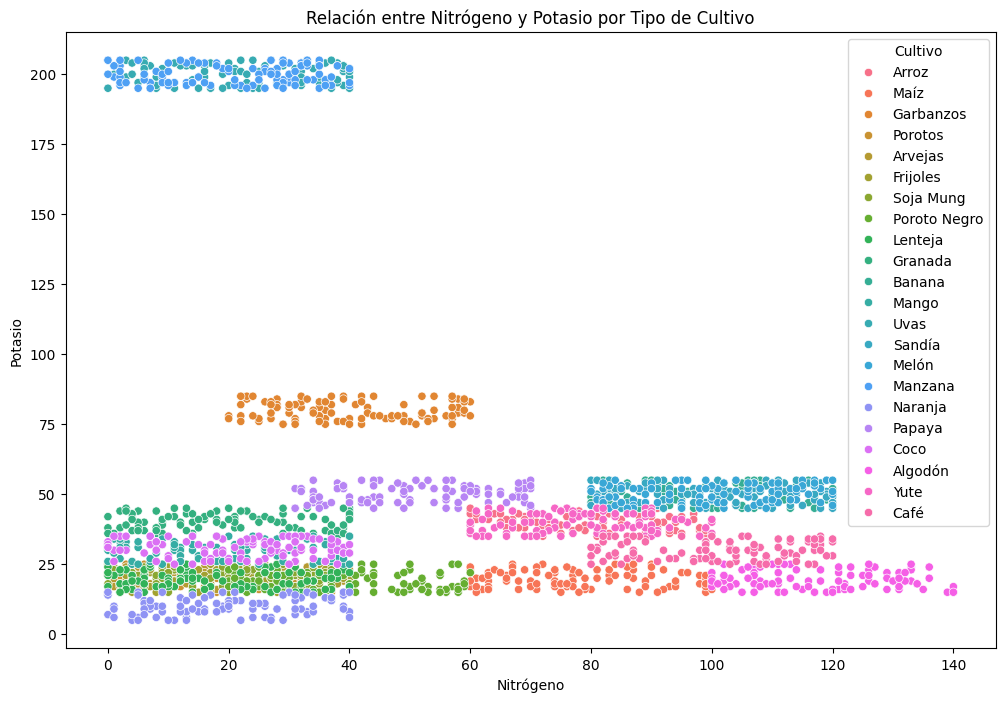

In [42]:
# Visualizamos la relación entre nitrógeno y potasio según el tipo de cultivo

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x='Nitrogeno',
    y='Potasio',
    hue='Cultivo'
)

plt.title('Relación entre Nitrógeno y Potasio por Tipo de Cultivo')
plt.xlabel('Nitrógeno')
plt.ylabel('Potasio')

plt.show()

In [43]:
# Insight:
# Se observan agrupamientos diferenciados entre cultivos según los niveles
# de nitrógeno y potasio presentes en el suelo, lo que sugiere que estas
# variables podrían resultar relevantes para los modelos de clasificación.

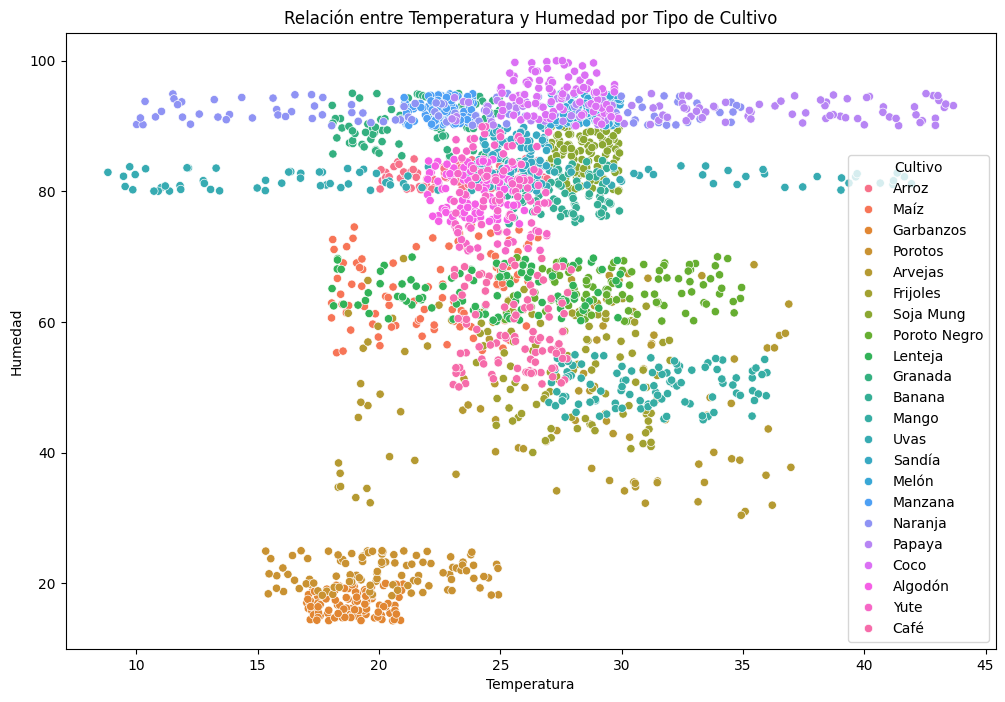

In [44]:
# Visualizamos la relación entre temperatura y humedad según el tipo de cultivo

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x='Temperatura',
    y='Humedad',
    hue='Cultivo'
)

plt.title('Relación entre Temperatura y Humedad por Tipo de Cultivo')
plt.xlabel('Temperatura')
plt.ylabel('Humedad')

plt.show()

In [45]:
# Insight:
# Se identifican patrones diferenciados entre cultivos según las condiciones
# de temperatura y humedad, lo que evidencia la influencia de las variables
# climáticas sobre la adaptación y selección de cada especie agrícola.

#**¿Las variables nutricionales y climáticas permiten diferenciar distintos tipos de cultivo?**

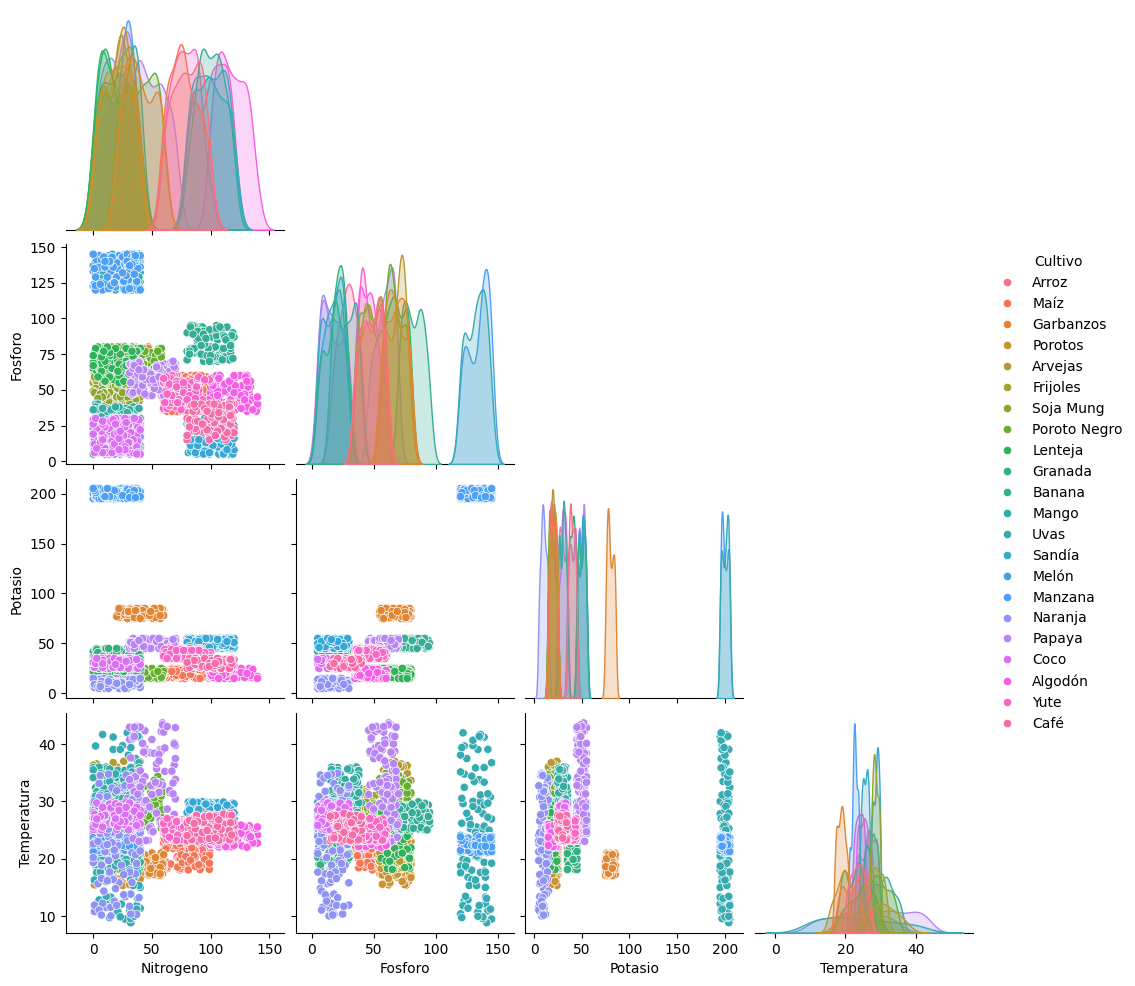

In [46]:
# Visualizamos relaciones entre variables numéricas relevantes según el tipo de cultivo
# mediante una matriz de gráficos de dispersión (pairplot)

sns.pairplot(
    df,
    hue='Cultivo',
    vars=['Nitrogeno', 'Fosforo', 'Potasio', 'Temperatura'],
    corner=True
)

plt.show()

#**8) Hallazgos del análisis exploratorio**

##**1) Balance del dataset**

El dataset presenta una distribución equilibrada entre los distintos tipos de cultivo, lo que resulta favorable para el entrenamiento de modelos de clasificación, reduciendo el riesgo de sesgo hacia determinadas especies agrícolas.

#**2) Relaciones entre variables numéricas**

El mapa de correlación mostró una correlación positiva moderada entre fósforo y potasio, mientras que el resto de las variables presentaron relaciones débiles o moderadas. Esto sugiere que la recomendación de cultivos depende de múltiples factores combinados y no únicamente de una sola variable agronómica.

#**3) Temperatura óptima según cultivo**

Se observaron diferencias claras en los rangos de temperatura asociados a determinados cultivos. Algunas especies mostraron adaptación a temperaturas elevadas, mientras que otras se concentraron en rangos térmicos más moderados, evidenciando distintos requerimientos climáticos.

#**4) Variabilidad del pH del suelo**

El análisis del pH permitió identificar que algunos cultivos toleran rangos relativamente amplios de acidez/alcalinidad, mientras que otros presentan comportamientos más específicos. Esto resalta la importancia del pH en la disponibilidad de nutrientes y adaptación del cultivo.

#**5) Humedad ambiental y adaptación agrícola**

Los gráficos de humedad evidenciaron diferencias marcadas entre cultivos. Algunas especies presentaron alta concentración en ambientes de elevada humedad, mientras que otras mostraron adaptación a condiciones más secas, reflejando distintos requerimientos fisiológicos.

#**6) Requerimientos de precipitaciones**

Las precipitaciones mostraron distribuciones considerablemente diferentes entre cultivos, identificándose especies asociadas a ambientes de alta disponibilidad hídrica y otras adaptadas a condiciones de menor precipitación.

#**7) Perfiles nutricionales diferenciados**

Los gráficos de dispersión entre nitrógeno, fósforo y potasio permitieron observar agrupamientos relativamente diferenciados entre cultivos, indicando que cada especie presenta requerimientos nutricionales particulares.

#**8) Influencia de variables climáticas**

La relación entre temperatura y humedad mostró agrupamientos parciales entre distintos cultivos, evidenciando que las condiciones climáticas son variables relevantes para la selección y adaptación agrícola.

##**9) Separación entre cultivos**

La matriz de dispersión permitió visualizar separaciones parciales entre especies agrícolas utilizando variables nutricionales y climáticas, lo que respalda la utilización de modelos de Machine Learning para desarrollar sistemas de recomendación de cultivos.

#**9) Ingeniería de atributos**

Con el objetivo de preparar los datos para los modelos de Machine Learning, se realizaron distintas transformaciones sobre las variables del dataset.

Entre las principales tareas de ingeniería de atributos se incluyen:

* Codificación de la variable objetivo mediante Label Encoding.
* Estandarización de variables numéricas utilizando StandardScaler.
* Traducción y estandarización de nombres de variables y cultivos.
* Separación entre variables predictoras y variable objetivo.

Estas transformaciones permitieron adaptar los datos para su utilización en modelos de clasificación supervisada.

#**10) Preparación de datos para Machine Learning**

In [47]:
# Separamos las variables predictoras y la variable objetivo

X = df.drop(columns='Cultivo')

y = df['Cultivo']

In [48]:
# Visualizamos la dimensión de las variables predictoras y objetivo

print(X.shape)
print(y.shape)

(2200, 7)
(2200,)


Como los cultivos son texto el modelo no los entiende directamente.




In [49]:
# Importamos LabelEncoder para transformar la variable objetivo

from sklearn.preprocessing import LabelEncoder

In [50]:
# Convertimos los nombres de cultivos a valores numéricos

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [51]:
# Visualizamos algunas clases codificadas

y_encoded[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [52]:
# Dividimos los datos en entrenamiento y prueba

from sklearn.model_selection import train_test_split

In [53]:
# Generamos conjuntos de entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

**¿Por qué stratify?**

Porque mantiene balanceadas las clases
y eso es muy importante en clasificación multiclase.

##**Escalado de variables**

In [54]:
# Importamos StandardScaler para normalizar las variables numéricas

from sklearn.preprocessing import StandardScaler

In [55]:
# Escalamos las variables predictoras

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#**11) Modelos de Machine Learning**

##**Regresión Logística**


##¿Qué desempeño obtiene un modelo lineal para clasificar cultivos?

In [56]:
# Importamos el modelo de Regresión Logística

from sklearn.linear_model import LogisticRegression

In [57]:
# Creamos el modelo de Regresión Logística

modelo_logistico = LogisticRegression(max_iter=5000)

In [58]:
# Entrenamos el modelo utilizando los datos escalados

modelo_logistico.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

In [59]:
# Generamos predicciones sobre el conjunto de prueba

y_pred_log = modelo_logistico.predict(X_test_scaled)

##Evaluación del modelo

In [60]:
# Importamos métricas de evaluación para clasificación

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [61]:
# Calculamos la precisión general del modelo

accuracy_log = accuracy_score(y_test, y_pred_log)

print(f'Accuracy: {accuracy_log:.4f}')

Accuracy: 0.9795


In [62]:
# Generamos el reporte de clasificación del modelo

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.95      0.95      0.95        20
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       0.95      1.00      0.98        20
           6       1.00      0.85      0.92        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       0.87      1.00      0.93        20
          10       0.95      1.00      0.98        20
          11       1.00      1.00      1.00        20
          12       0.95      1.00      0.98        20
          13       1.00      1.00      1.00        20
          14       1.00      0.95      0.97        20
          15       1.00      1.00      1.00        20
          16       1.00      0.90      0.95        20
          17       1.00    

#Matriz de confusión

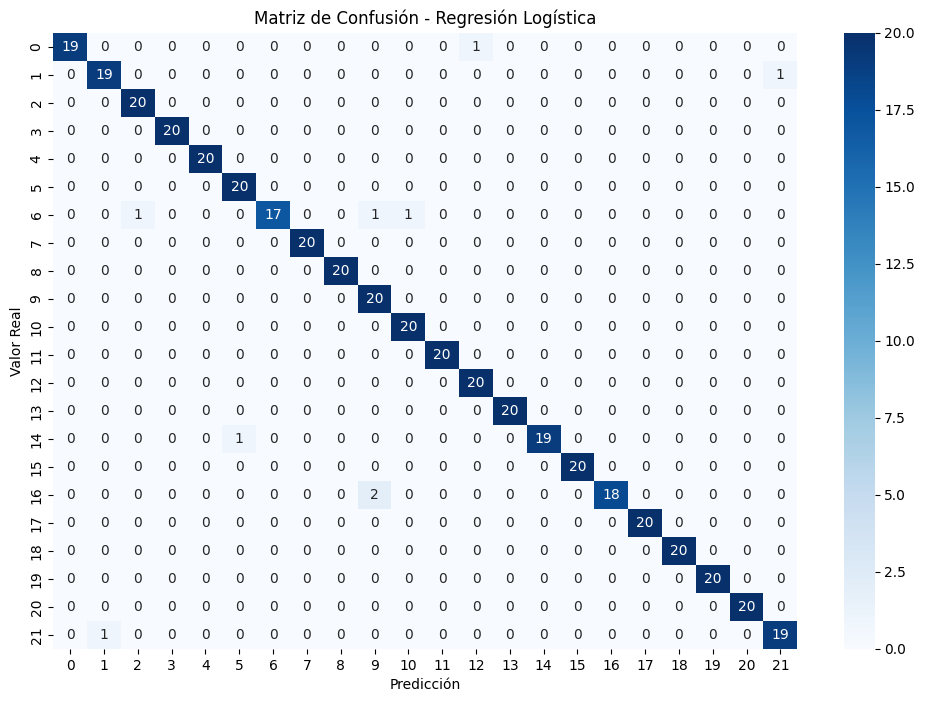

In [63]:
# Visualizamos la matriz de confusión del modelo

plt.figure(figsize=(12,8))

sns.heatmap(
    confusion_matrix(y_test, y_pred_log),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

##**Interpretación**

Esto indica que:

*  Las variables del suelo y clima poseen alto poder discriminatorio.
*  Distintos cultivos presentan perfiles edáficos y climáticos relativamente diferenciados.
*  El modelo logra identificar patrones consistentes entre nutrientes, temperatura, humedad, pH y precipitaciones.




In [64]:
# Insight:
# El modelo de Regresión Logística alcanzó una precisión superior al 97%,
# mostrando una elevada capacidad para diferenciar cultivos a partir de variables
# climáticas y nutricionales. La matriz de confusión evidencia una baja cantidad
# de errores de clasificación, indicando que las variables analizadas poseen
# un alto valor predictivo para sistemas de recomendación agrícola.

#**Entrenar Random Forest**

##¿Un modelo basado en árboles de decisión mejora la clasificación de cultivos?

In [65]:
# Importamos el modelo Random Forest para clasificación

from sklearn.ensemble import RandomForestClassifier

In [66]:
# Creamos el modelo Random Forest

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [67]:
# Entrenamos el modelo con los datos de entrenamiento

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [68]:
# Generamos predicciones sobre el conjunto de prueba

y_pred_rf = modelo_rf.predict(X_test)

##**Evaluación del modelo**

In [69]:
# Calculamos la precisión general del modelo

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f'Accuracy: {accuracy_rf:.4f}')

Accuracy: 0.9977


In [70]:
# Generamos el reporte de clasificación del modelo

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      0.95      0.97        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       0.95      1.00      0.98        20
          10       1.00      1.00      1.00        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

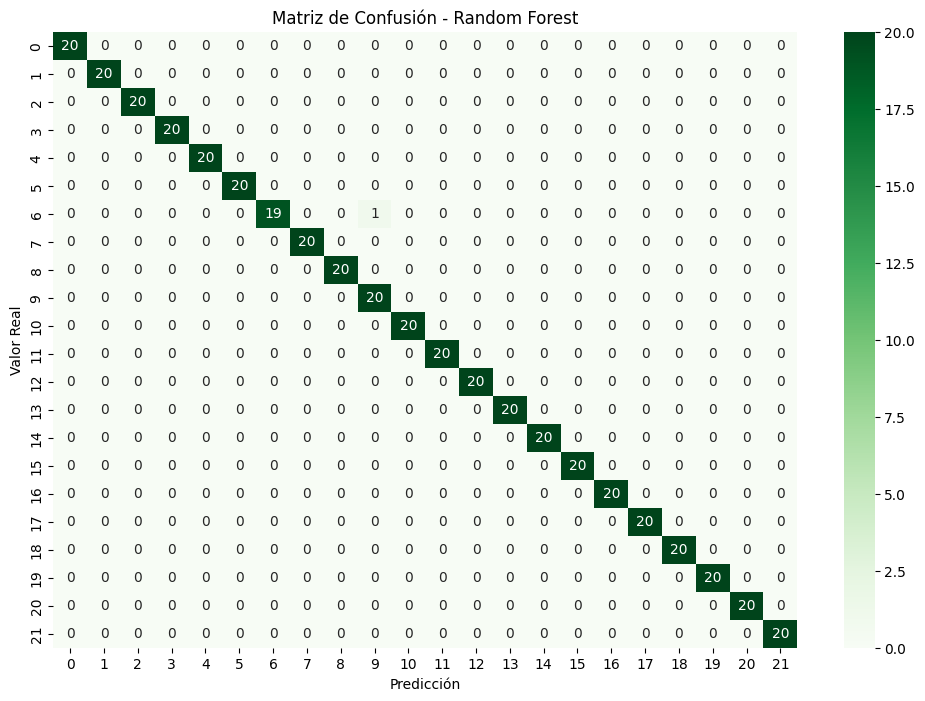

In [71]:
# Visualizamos la matriz de confusión del modelo Random Forest

plt.figure(figsize=(12,8))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

**Interpretación:** El modelo Random Forest logró un desempeño superior al modelo de Regresión Logística, indicando que las relaciones entre las variables del suelo y clima presentan comportamientos no lineales que son mejor capturados por modelos basados en árboles de decisión.

In [72]:
# Insight:
# El modelo Random Forest obtuvo la mejor performance, alcanzando una precisión
# cercana al 100% en la clasificación de cultivos. Esto sugiere que las variables
# climáticas y nutricionales utilizadas contienen patrones altamente diferenciables
# entre especies agrícolas, permitiendo construir sistemas de recomendación con
# elevado potencial predictivo.

#**12) Validación cruzada**

In [73]:
# Importamos cross_val_score para evaluar modelos mediante validación cruzada

from sklearn.model_selection import cross_val_score

In [74]:
# Evaluamos el modelo de Regresión Logística con validación cruzada

scores_log = cross_val_score(
    modelo_logistico,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(scores_log)
print(f'Accuracy promedio Regresión Logística: {scores_log.mean():.4f}')

[0.97727273 0.97727273 0.96590909 0.96306818 0.97443182]
Accuracy promedio Regresión Logística: 0.9716


In [75]:
# Evaluamos el modelo Random Forest con validación cruzada

scores_rf = cross_val_score(
    modelo_rf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(scores_rf)
print(f'Accuracy promedio Random Forest: {scores_rf.mean():.4f}')

[0.99431818 1.         0.98863636 0.99715909 0.99431818]
Accuracy promedio Random Forest: 0.9949


In [76]:
# Insight:
# La validación cruzada permite evaluar la estabilidad de los modelos utilizando
# distintas particiones de los datos. Esto ayuda a verificar que el buen desempeño
# observado no dependa únicamente de una división particular entre entrenamiento y prueba.

#**13) Importancia de variables**

##**¿Qué variables influyen más en la recomendación del cultivo?**

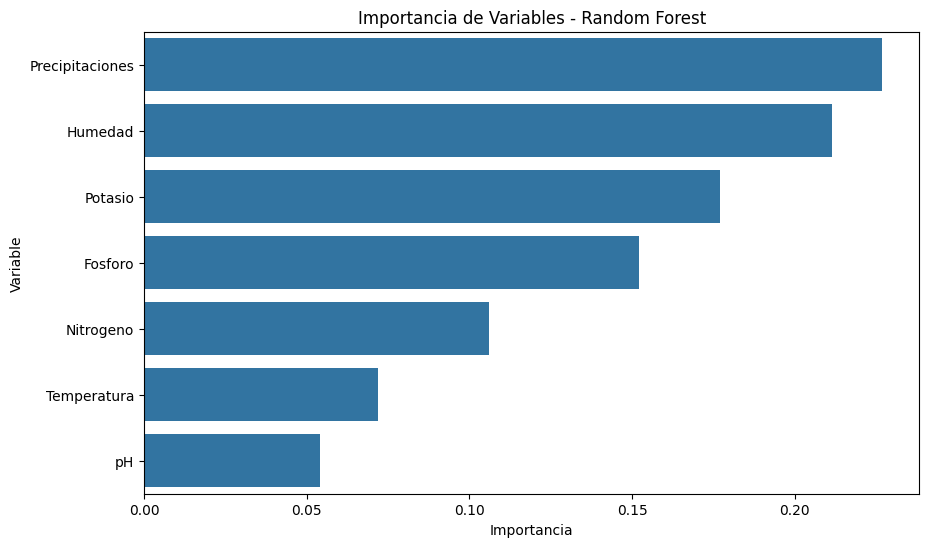

In [77]:
# Visualizamos la importancia de las variables en el modelo Random Forest

importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by='Importancia',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias,
    x='Importancia',
    y='Variable'
)

plt.title('Importancia de Variables - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')

plt.show()

##**Interpretación**


##**1) Precipitaciones y humedad**

Fueron las variables más importantes.

Esto tiene muchísimo sentido agronómico porque:


*   La disponibilidad hídrica condiciona directamente la adaptación del cultivo.
*   Define estrés hídrico.
*   Afecta absorción de nutrientes.
*   Limita productividad.









##**2) Potasio y fósforo**

También tuvieron alta importancia.

Lo cual indica que:

* Los requerimientos nutricionales son determinantes.
* Especialmente en desarrollo radicular, floración y rendimiento.

##**3) Temperatura**

Tuvo importancia moderada.

Esto sugiere que, si bien influye en el desarrollo fisiológico, otros factores como disponibilidad hídrica y nutrición generan mayor diferenciación entre cultivos en este dataset.

##**4) pH**

Fue la variable menos relevante.

Posiblemente porque muchos cultivos comparten rangos similares de pH
o porque el dataset presenta menor variabilidad en esta variable.

In [78]:
# Insight:
# El análisis de importancia de variables mostró que las precipitaciones y la humedad
# fueron los factores más relevantes para la clasificación de cultivos, destacando
# la influencia de la disponibilidad hídrica en la adaptación agrícola.
# Asimismo, nutrientes como potasio y fósforo también presentaron elevada importancia,
# evidenciando el rol de la fertilidad del suelo en la selección del cultivo adecuado.
# En contraste, variables como el pH mostraron menor capacidad discriminatoria dentro
# del dataset analizado.

#**14) Optimización de hiperparámetros (GridSearchCV)**

In [79]:
# Importamos GridSearchCV para optimización de hiperparámetros

from sklearn.model_selection import GridSearchCV

In [80]:
# Definimos la grilla de hiperparámetros para Random Forest

parametros = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [81]:
# Creamos el modelo base de Random Forest

rf = RandomForestClassifier(random_state=42)

In [82]:
# Configuramos GridSearchCV para buscar la mejor combinación de hiperparámetros

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=parametros,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [83]:
# Entrenamos GridSearchCV

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

##**Mejores parámetros encontrados**

In [84]:
# Visualizamos los mejores hiperparámetros encontrados

print(grid_search.best_params_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


##**Mejor score**

In [85]:
# Visualizamos el mejor resultado obtenido en validación cruzada

print(grid_search.best_score_)

0.9954545454545454


##**Evaluamos el mejor modelo**

In [86]:
# Obtenemos el mejor modelo encontrado

mejor_modelo = grid_search.best_estimator_

In [87]:
# Generamos predicciones utilizando el mejor modelo

y_pred_best = mejor_modelo.predict(X_test)

In [88]:
# Evaluamos el accuracy del mejor modelo

accuracy_best = accuracy_score(y_test, y_pred_best)

print(f'Accuracy optimizado: {accuracy_best:.4f}')

Accuracy optimizado: 0.9977


##**15) Comparacion y selección del mejor modelo**

In [89]:
# Comparamos el desempeño de los modelos evaluados

resultados_modelos = pd.DataFrame({
    'Modelo': [
        'Regresión Logística',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_log,
        accuracy_rf
    ]
})

resultados_modelos

,Modelo,Accuracy
0,Regresión Logística,0.979545
1,Random Forest,0.997727


In [ ]:
# Insight:
# El modelo Random Forest presentó el mejor desempeño general,
# alcanzando la mayor precisión entre los modelos evaluados.
# Por este motivo, fue seleccionado como el modelo más adecuado
# para el sistema de recomendación de cultivos desarrollado.

#**16) Conclusión final del proyecto**

El proyecto permitió comprobar que las variables climáticas y nutricionales poseen una elevada capacidad para diferenciar distintos tipos de cultivo.

A través del análisis exploratorio de datos se identificaron patrones asociados a humedad, precipitaciones, temperatura y nutrientes del suelo, los cuales fueron posteriormente aprovechados por los modelos de Machine Learning para realizar la clasificación de cultivos.

Entre los modelos evaluados, Random Forest presentó el mejor desempeño, alcanzando una precisión cercana al 100%, lo que evidencia el potencial de la inteligencia artificial aplicada a sistemas de recomendación agrícola.

Asimismo, el análisis de importancia de variables mostró que las precipitaciones y la humedad fueron los factores más relevantes dentro del modelo predictivo, destacando la influencia de la disponibilidad hídrica en la adaptación de los cultivos.

En conjunto, los resultados obtenidos demuestran cómo la integración entre agronomía, análisis de datos y Machine Learning puede contribuir al desarrollo de herramientas orientadas a mejorar la toma de decisiones en el sector agropecuario mediante enfoques basados en datos.